
## **Neural Network Functions**
Single Layer Neural Network

In [737]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd

### **Forward Functions**

In [738]:

# get Z
def linear_combination(X:np.array, W:np.array, b:np.array)->np.array:
    if (W.shape[1] != X.shape[0]) | (W.shape[0] != b.shape[0]):
        raise ValueError("The dimensions do not match")


    Z = W @ X + b

    #print(f'Z = {W.shape} x {X.shape} + {b.shape}', end = '')


    return Z
# get dummies of y
def dummy(y:np.array, k:int)->np.array:
    list_cats = [i for i in range(k)]
    dummy_y = []
    for i in range(len(list_cats)):
        list = [1 if y[j] == list_cats[i] else 0 for j in range(len(y))]
        dummy_y.append(list)
    return np.array(dummy_y)
# relu and relu backward
def relu(Z):
    return np.maximum(0, Z)

def relu_backward(Z):
    return (Z > 0).astype(int)

# softmax
def softmax(Z:np.array) -> np.array:

    max_matrix = np.max(Z, axis = 0, keepdims = True)
    shifted_value = np.exp(Z - max_matrix)

    sum_matrix = np.sum(shifted_value, axis = 0, keepdims = True)

    softmax = shifted_value / sum_matrix

    return np.array(softmax)



### **Backward Functions**

In [739]:

# observing the loss using mle 
def cross_entropy_loss(y:np.array, y_hat:np.array):

    n = y.shape[1]
    
    
    y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)

    ln_y_hat = np.log(y_hat)

    cross_term = y * ln_y_hat

    sum_cross = np.sum(cross_term)

    return -1/n * sum_cross

# last hidden layer gradient
def compute_output_gradient(Y:np.array, A2:np.array): # Y is the one-hot-encoded and A2 is the softmax predicted probabilities A2 = softmax(Z)
    '''
    **Output Gradient**: Computes the gradient of the output Z\\
    softmax output - true values
    '''
    dZ2 = A2 - Y
    return dZ2

def compute_parameter_gradients(dZ:np.array, A1:np.array): 
    '''
        **Parameter Gradient**: Computes the gradient of the output weights and bias\\
        dZ2 (K, N) and A1 (m, N) where A1 is the activation matrix coming from relu(Z1)
    '''

    n = dZ.shape[1]

    dW = 1/n * dZ @ A1.T

    db = 1/n * np.sum(dZ, axis = 1, keepdims = True)

    return dW, db

# backpropagation from hidden layer 2 --> hidden layer 1
def backprop_hidden_layer(dZ2:np.array, W2:np.array, Z1:np.array, X:np.array):


    '''
    **Returning to previous Hidden Layer**: This function gets the backporpagation from hidden layer 2 --> hidden layer 1 \\
    - dZ2 = Gradient of the loss with respect to Layer 2 logits, shape (K, N)\\
    - W2 = Weight matrix of Layer 2, shape (K, m)\\
    - Z1 = Weight matrix of Layer 2, shape (K, m)\\
    - X = input data matrix, shape (d, N)\\
    **dA1** = transpose(W2) * dZ2 (*The integration term returning back to hidden layer 1*)\\
    **dZ1** = dA1 * ReLU_backward(Z1) (*Getting the fractional value before ReLU*)\\
    **dW1** = 1/N * dZ1 * transpose(X) (*Deriving the Weight with respect to hidden layer 1*)\\
    **db1** = 1/N * sum(dZ1) (*Deriving the bias with respect to hidden layer 1*)
    '''


    n = X.shape[1]
    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_backward(Z1)
    dW1 = 1/n * dZ1 @ X.T
    db1 = 1/n * np.sum(dZ1, axis = 1, keepdims = True)

    return dW1, db1

# gradient descent of previous layer
def gradient_descent(params:dict, grads:dict, learning_rate:float)->dict:
    '''
    **Gradient Descent Layer 1**: Update the weights and the biases in the network usiong standard gradient descent optimization rule

    params are W1, W2, b1, b2 grads are dW1, dW2, db1, db2\\
    learning rate is eta 
    ''' 

    update = {}
    
    for key in params:
        update[key] = params[key] - learning_rate * grads['d' + key]

    return update



Each Iteration of the neural network
```
X, Y
          │
  ┌───────▼───────┐
  │ 1. Forward   │ ──► Z1 = W1@X + b1
  │    Pass       │ ──► A1 = relu(Z1)
  └───────┬───────┘ ──► Z2 = W2@A1 + b2
          │         ──► A2 = softmax(Z2)
  ┌───────▼───────┐
  │ 2. Loss Eval  │ ──► loss = cross_entropy(Y, A2)
  └───────┬───────┘
          │
  ┌───────▼───────┐
  │ 3. Backward   │ ──► dZ2 = compute_output_gradient(Y, A2)
  │    Pass       │ ──► dW2, db2 = compute_out

```

### **Sample data for 2-layer**

In [740]:
d = 4
N = 500
K = 3
m = 4 # how many linear combination lines from layer to layer

np.random.seed(42)

x0 = np.random.normal(loc=0.0, scale=1.0, size=N)

x1 = np.random.poisson(lam=3.0, size=N)

x2 = np.random.binomial(n=10, p=0.5, size=N)

x3 = np.random.gamma(shape=2.0, scale=2.0, size=N)

X = np.vstack([x0, x1, x2, x3])

# AI Generated Y
#score = (2.0 * x0) - (1.5 * x1) + (0.8 * x2) - (1.2 * x3)
#y = (score > np.median(score)).astype(int)

y = np.random.randint(0, K, size=N) # some random y


# initial weights and bias
W1 = np.random.randn(m, d) 
b1 = np.random.randn(m, 1)
W2 = np.random.randn(K, m) 
b2 = np.random.randn(K, 1)

params = {
    'W1': W1,
    'b1': b1,
    'W2': W2,
    'b2': b2
}

iteration = {
    'Count': [],
    'Loss' : []
}

dummy_y = dummy(y, K)

summary_X = pd.DataFrame(X.T)

summary_X.describe(include = 'all')

,0,1,2,3
count,500.000000,500.000000,500.000000,500.000000
mean,0.006838,2.984000,5.008000,4.164191
std,0.981253,1.712779,1.617767,3.058547
min,-3.241267,0.000000,0.000000,0.051721
25%,-0.700307,2.000000,4.000000,1.976340
50%,0.012797,3.000000,5.000000,3.486682
75%,0.636783,4.000000,6.000000,5.466098
max,3.852731,8.000000,9.000000,27.220465


In [741]:

'''
# This code shows how one single iteration works

Z1 = linear_combination(X, params['W1'], params['b1'])
A1 = relu(Z1)

Z2 = linear_combination(A1, params['W2'], params['b2'])
A2 = softmax(Z2)

dummy_y = dummy(y, K)

loss = cross_entropy_loss(dummy_y, A2)

iteration['Loss'].append(loss)

dZ2 = compute_output_gradient(dummy_y, A2)

dW2, db2 = compute_parameter_gradients(dZ2, A1)

dW1, db1 = backprop_hidden_layer(dZ2, params['W2'], Z1, X)

grads = {
    'dW1': dW1,
    'db1': db1,
    'dW2': dW2,
    'db2': db2
}

learning_rate = 1e-2

updated_params = gradient_descent(params, grads, learning_rate=learning_rate)

params = updated_params
'''



"\n# This code shows how one single iteration works\n\nZ1 = linear_combination(X, params['W1'], params['b1'])\nA1 = relu(Z1)\n\nZ2 = linear_combination(A1, params['W2'], params['b2'])\nA2 = softmax(Z2)\n\ndummy_y = dummy(y, K)\n\nloss = cross_entropy_loss(dummy_y, A2)\n\niteration['Loss'].append(loss)\n\ndZ2 = compute_output_gradient(dummy_y, A2)\n\ndW2, db2 = compute_parameter_gradients(dZ2, A1)\n\ndW1, db1 = backprop_hidden_layer(dZ2, params['W2'], Z1, X)\n\ngrads = {\n    'dW1': dW1,\n    'db1': db1,\n    'dW2': dW2,\n    'db2': db2\n}\n\nlearning_rate = 1e-2\n\nupdated_params = gradient_descent(params, grads, learning_rate=learning_rate)\n\nparams = updated_params\n"

In [742]:

max_iter = 1000
pbar = tqdm(range(max_iter), desc="Converging Neural Network")


for i in pbar:

    Z1 = linear_combination(X, params['W1'], params['b1'])
    A1 = relu(Z1)

    Z2 = linear_combination(A1, params['W2'], params['b2'])
    A2 = softmax(Z2)

    loss = cross_entropy_loss(dummy_y, A2)

    iteration['Loss'].append(loss)

    dZ2 = compute_output_gradient(dummy_y, A2)

    dW2, db2 = compute_parameter_gradients(dZ2, A1)

    dW1, db1 = backprop_hidden_layer(dZ2, params['W2'], Z1, X)

    grads = {
        'dW1': dW1,
        'db1': db1,
        'dW2': dW2,
        'db2': db2
    }

    learning_rate = 1e-2

    updated_params = gradient_descent(params, grads, learning_rate=learning_rate)

    params = updated_params

    iteration['Count'].append(i+1)



Converging Neural Network: 100%|██████████| 1000/1000 [00:00<00:00, 3260.71it/s]


In [743]:

true_classes = np.argmax(dummy_y, axis=0)
predicted_classes = np.argmax(A2, axis=0)
accuracy = np.mean(true_classes == predicted_classes) * 100
print(f'\nModel Accuracy: {accuracy:.2f}%')


Model Accuracy: 37.80%


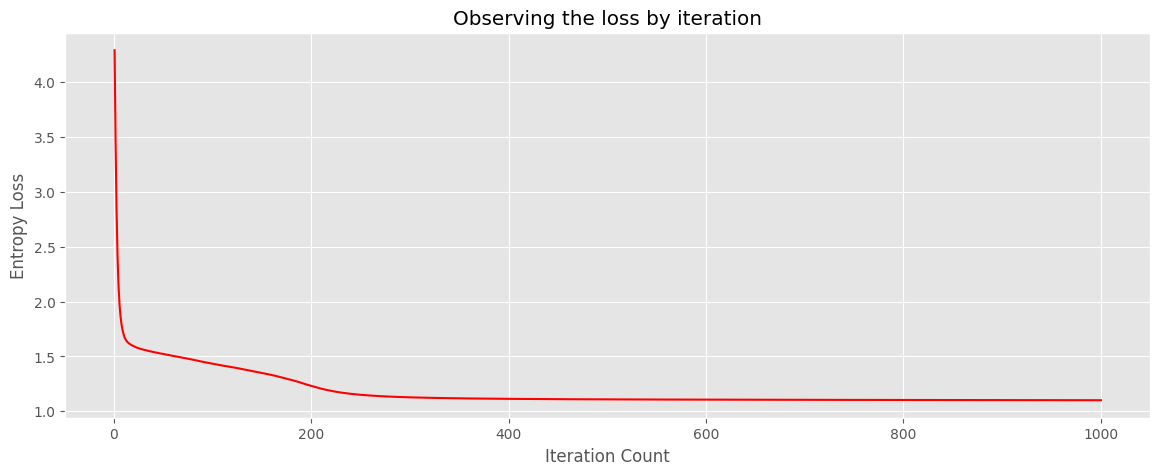

In [744]:
final_iteration = iteration.copy()
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
plt.style.use('ggplot')
sns.lineplot(x = final_iteration['Count'], y = final_iteration['Loss'], color = 'red')
plt.title('Observing the loss by iteration')
plt.xlabel('Iteration Count')
plt.ylabel('Entropy Loss')
plt.show()

In [745]:
def predict_new_obs(X_new:np.array, params:dict):
    Z1 = linear_combination(X_new, params['W1'], params['b1'])
    A1 = relu(Z1)

    Z2 = linear_combination(A1, params['W2'], params['b2'])
    A2 = softmax(Z2)

    return A2, np.argmax(A2, axis=0)

#np.random.seed(42)

x0 = np.random.normal(loc=0.0, scale=1.0)
x1 = np.random.poisson(lam=3.0)
x2 = np.random.binomial(n=10, p=0.5)
x3 = np.random.gamma(shape=2.0, scale=2.0)

x_new = np.array([[x0], [x1], [x2], [x3]])

new_prediction, selected_cat = predict_new_obs(x_new, params = params)
print(f'Predicted Probabilities: \n{new_prediction}\nOutput Result (Category): {selected_cat}')

Predicted Probabilities: 
[[0.25430619]
 [0.33971901]
 [0.4059748 ]]
Output Result (Category): [2]


## **L-layer Forward and Backward**
looping on the weights and working on the L iterations where L-1 are hidden layers and 1 output layer

```

Input A_0 = X
    │
    ▼
┌──────────────────────────────────────────┐
│  For l = 1, 2, ..., L-1 (Hidden Layers)  │
│  • Z_l = W_l @ A_{l-1} + b_l             │
│  • A_l = ReLU(Z_l)                       │
│  • Store (A_{l-1}, Z_l, W_l, b_l) in Cache│
└──────────────────┬───────────────────────┘
                   │
                   ▼
┌──────────────────────────────────────────┐
│  For l = L (Output Layer)                │
│  • Z_L = W_L @ A_{L-1} + b_L             │
│  • A_L = Softmax(Z_L)                    │
│  • Store (A_{L-1}, Z_L, W_L, b_L) in Cache│
└──────────────────┬───────────────────────┘
                   │
                   ▼
     Loss Evaluation: L(Y, A_L)


```
Loss L (from Y and A_L)
    │
    ▼
┌──────────────────────────────────────────┐
│  Step 1: Output Layer Gradient (l = L)   │
│  • dZ_L = A_L - Y                        │
│  • dW_L = (1/N) * dZ_L @ (A_{L-1})^T     │
│  • db_L = (1/N) * sum(dZ_L, axis=1)      │
└──────────────────┬───────────────────────┘
                   │
                   ▼
┌──────────────────────────────────────────┐
│  Step 2: Loop for l = L-1 down to 1      │
│  • dA_l = (W_{l+1})^T @ dZ_{l+1}         │
│  • dZ_l = dA_l * relu_backward(Z_l)      │
│  • dW_l = (1/N) * dZ_l @ (A_{l-1})^T     │
│  • db_l = (1/N) * sum(dZ_l, axis=1)      │
└──────────────────────────────────────────┘

### **Sample data for L-layer data**

In [746]:
d = 60
N = 2500
K = 3
m = 4 # how many linear combination lines (Neurons) from layer to layer

L = 5 

np.random.seed(42)

X = np.random.randn(d, N)

# AI Generated Y
#score = (2.0 * x0) - (1.5 * x1) + (0.8 * x2) - (1.2 * x3)
#y = (score > np.median(score)).astype(int)

y = np.random.randint(0, K, size=N) # some random y


iteration = {
    'Count': [],
    'Loss' : []
}

dummy_y = dummy(y, K)

data = {
    'A': {0: X},  
    'Z': {},
    'W': {},      
    'b': {},
    'dZ': {},    
    'dW': {},
    'db': {}
}

iteration = {
    'Count': [],
    'Loss' : []
}


# initializing weights and biases
layer_dims = [d] + [m] * (L - 1) + [K]

for l in range(1, L+1):
    n_in = layer_dims[l-1]
    n_out = layer_dims[l]

    data['W'][l] = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in) # This strategy is called He (Kaiming) Initialization, and its core purpose is Variance Preservation.
    data['b'][l] = np.zeros((n_out, 1)) # Biases merely shift the activation thresholds and do not multiply input signals, so they do not contribute to variance explosion.
    

### **Forward Computation for L-layers**

In [747]:
'''

# Hidden layers (1 to L-1)
for l in range(1, L):
    data['Z'][l] = linear_combination(data['A'][l-1], data['W'][l], data['b'][l])
    data['A'][l] = relu(data['Z'][l])

# Output layer (L)
data['Z'][L] = linear_combination(data['A'][L-1], data['W'][L], data['b'][L])
data['A'][L] = softmax(data['Z'][L])

'''

"\n\n# Hidden layers (1 to L-1)\nfor l in range(1, L):\n    data['Z'][l] = linear_combination(data['A'][l-1], data['W'][l], data['b'][l])\n    data['A'][l] = relu(data['Z'][l])\n\n# Output layer (L)\ndata['Z'][L] = linear_combination(data['A'][L-1], data['W'][L], data['b'][L])\ndata['A'][L] = softmax(data['Z'][L])\n\n"

### **Backward Computation for L-layers**

In [748]:
'''

loss = cross_entropy_loss(dummy_y, data['A'][L])
iteration['Loss'].append(loss)

data['dZ'][L] = compute_output_gradient(dummy_y, data['A'][L])
data['dW'][L], data['db'][L] = compute_parameter_gradients(data['dZ'][L], data['A'][L-1])
for l in range(L-1, 0, -1):
    dA = data['W'][l+1].T @ data['dZ'][l+1]
    data['dZ'][l] = dA * relu_backward(data['Z'][l])
    data['dW'][l], data['db'][l] = compute_parameter_gradients(data['dZ'][l], data['A'][l-1])

for l in range(1, L+1):
    data['W'][l] = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in)
    data['b'][l] = np.zeros((n_out, 1))
    
'''

"\n\nloss = cross_entropy_loss(dummy_y, data['A'][L])\niteration['Loss'].append(loss)\n\ndata['dZ'][L] = compute_output_gradient(dummy_y, data['A'][L])\ndata['dW'][L], data['db'][L] = compute_parameter_gradients(data['dZ'][L], data['A'][L-1])\nfor l in range(L-1, 0, -1):\n    dA = data['W'][l+1].T @ data['dZ'][l+1]\n    data['dZ'][l] = dA * relu_backward(data['Z'][l])\n    data['dW'][l], data['db'][l] = compute_parameter_gradients(data['dZ'][l], data['A'][l-1])\n\nfor l in range(1, L+1):\n    data['W'][l] = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in)\n    data['b'][l] = np.zeros((n_out, 1))\n\n"

### **Iterative L-layers for both Forward and Backward**

In [749]:
max_iter = 50
pbar = tqdm(range(max_iter), desc="Converging Neural Network")
learning_rate = 0.01

for i in pbar:

    for l in range(1, L):
        data['Z'][l] = linear_combination(data['A'][l-1], data['W'][l], data['b'][l])
        data['A'][l] = relu(data['Z'][l])

    # Output layer (L)
    data['Z'][L] = linear_combination(data['A'][L-1], data['W'][L], data['b'][L])
    data['A'][L] = softmax(data['Z'][L])

    loss = cross_entropy_loss(dummy_y, data['A'][L])
    iteration['Loss'].append(loss)

    data['dZ'][L] = compute_output_gradient(dummy_y, data['A'][L])
    data['dW'][L], data['db'][L] = compute_parameter_gradients(data['dZ'][L], data['A'][L-1])
    for l in range(L-1, 0, -1):
        dA = data['W'][l+1].T @ data['dZ'][l+1]
        data['dZ'][l] = dA * relu_backward(data['Z'][l])
        data['dW'][l], data['db'][l] = compute_parameter_gradients(data['dZ'][l], data['A'][l-1])

    for l in range(1, L+1):
        data['W'][l] -= learning_rate * data['dW'][l]
        data['b'][l] -= learning_rate * data['db'][l]

    iteration['Count'].append(i+1)
    pbar.set_postfix({'loss': loss})

Converging Neural Network: 100%|██████████| 50/50 [00:00<00:00, 321.12it/s, loss=1.11]


In [750]:

true_classes = np.argmax(dummy_y, axis=0)
predicted_classes = np.argmax(data['A'][L], axis=0)
accuracy = np.mean(true_classes == predicted_classes) * 100
print(f'\nModel Accuracy: {accuracy:.2f}%')


Model Accuracy: 34.52%


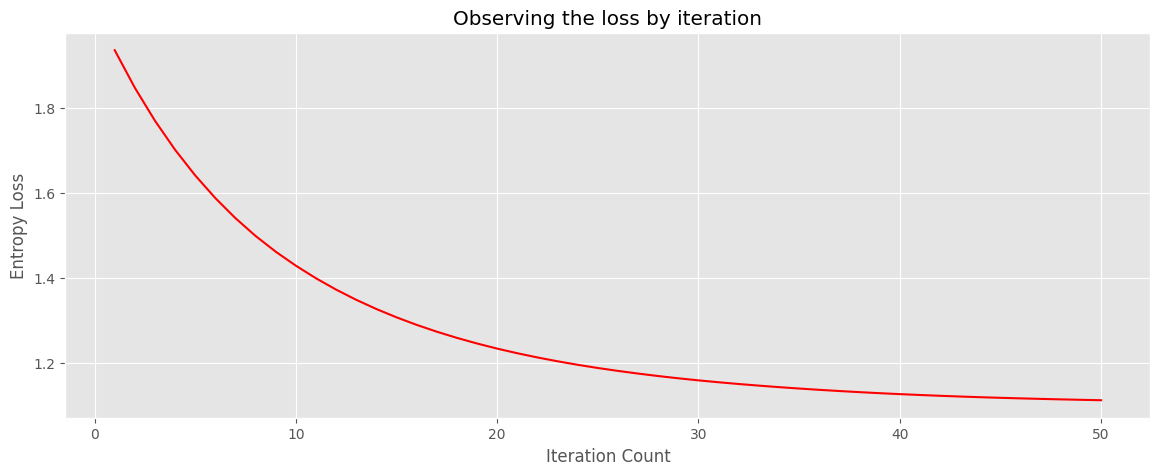

In [751]:
final_iteration = iteration.copy()
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
plt.style.use('ggplot')
sns.lineplot(x = final_iteration['Count'], y = final_iteration['Loss'], color = 'red')
plt.title('Observing the loss by iteration')
plt.xlabel('Iteration Count')
plt.ylabel('Entropy Loss')
plt.show()

In [ ]:
def predict_new_obs(X_new: np.ndarray, data: dict, L: int):
    A = {0: X_new}
    for l in range(1, L):
        Z = linear_combination(A[l-1], data['W'][l], data['b'][l])
        A[l] = relu(Z)
    Z_out = linear_combination(A[L-1], data['W'][L], data['b'][L])
    A_out = softmax(Z_out)
    return A_out, np.argmax(A_out, axis=0)

np.random.seed(42)

N_new = 5
X_new = np.random.randn(d, N_new)

new_prediction, selected_cat = predict_new_obs(X_new, data, L)
print(f'Predicted Probabilities: \n{new_prediction}\nOutput Result (Category): {selected_cat}')

Predicted Probabilities: 
[[0.3507706  0.33597063 0.34705509 0.25395306 0.33972016]
 [0.30955741 0.34664593 0.31200685 0.45366366 0.32173848]
 [0.33967198 0.31738344 0.34093806 0.29238328 0.33854136]]
Output Result (Category): [0 1 0 1 0]
